# Gated Recurrent Units for session-based next item prediction

Patricio Cerda, Bastián Mavrakis, Denis Parra

### Ambiente: Python3 + GPU

In [1]:
!pip install "numpy<2.0" --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 134.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for numpy: filename=numpy-1.26.4-cp313-cp313-linux_x86_64.whl size=6917452 sha256=24e6e34a96839ce11bd5df5b7b022ac3f420bd1ccfd4379ea66b181ea00c8484
  Stored in directory: /root/.cache/pip/wheels/8b/2d/9f/b6b46373f328e2ef50388915d351ccacbedac929459b5459bf
Successfully built numpy
  Attempting uninstall: numpy
    Found existing installation: numpy 2.1.3
    Uninstalling numpy-2.1.3:
      Successfully uninstalled numpy-2.1.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 5.0.0.93 requires nu

## Descargar datos y repositorio

In [1]:
# Clone repo
!git clone https://github.com/hidasib/GRU4Rec_PyTorch_Official --single-branch src

fatal: destination path 'src' already exists and is not an empty directory.


In [2]:
# Download RecSys Challenge 2015 dataset
!rm -r sample_data
!curl https://s3-eu-west-1.amazonaws.com/yc-rdata/yoochoose-data.7z --output data.7z

rm: cannot remove 'sample_data': No such file or directory
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  273M  100  273M    0     0  17.2M      0  0:00:15  0:00:15 --:--:-- 20.0M


In [3]:
# Extract dataset
!7z e data.7z -o./rsc15
!rm data.7z
!mkdir data


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,12 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (50657),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         1 file, 287211932 bytes (274 MiB)

Extracting archive: data.7z
--
Path = data.7z
Type = 7z
Physical Size = 287211932
Headers Size = 255
Method = LZMA:24
Solid = +
Blocks = 2

  0%    
Would you like to replace the existing file:
  Path:     ./rsc15/yoochoose-buys.dat
  Size:     55583744 bytes (54 MiB)
  Modified: 2014-11-05 14:25:04
with the file from archive:
  Path:     yoochoose-buys.dat
  Size:     55583744 bytes (54 MiB)
  Modified: 2014-11-05 14:25:04
? (Y)es / (N)o / (A)lways / (S)kip all / A(u)to rename all / (Q)uit? y

  0% - yoochoose-buys.dat                           1% - yoochoose-buys.dat                         

# Preprocesar dataset

In [4]:
import numpy as np
print(f"Versión de numpy: {np.__version__}")

Versión de numpy: 1.26.4


In [5]:
import os
import numpy as np
import pandas as pd
import datetime as dt
from matplotlib import pyplot as plt
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [6]:
src_path = './rsc15/'
dst_path   = './data/'

In [7]:
def process(src_path, dst_path):
  data = pd.read_csv(src_path + 'yoochoose-clicks.dat', sep=',', header=None, usecols=[0,1,2], dtype={0:np.int32, 1:str, 2:np.int64})
  data.columns = ['SessionId', 'TimeStr', 'ItemId']

  # Add timestamp
  data['Time'] = data.TimeStr.apply(lambda x: dt.datetime.strptime(x, '%Y-%m-%dT%H:%M:%S.%fZ').timestamp())
  del(data['TimeStr'])

  # Filter by session size > 1
  session_lengths = data.groupby('SessionId').size()
  data = data[np.in1d(data.SessionId, session_lengths[session_lengths>1].index)]

  # Filter by "known" (appears >= 5) items
  item_supports = data.groupby('ItemId').size()
  data = data[np.in1d(data.ItemId, item_supports[item_supports>=5].index)]

  # Filter by session size > 2
  session_lengths = data.groupby('SessionId').size()
  data = data[np.in1d(data.SessionId, session_lengths[session_lengths>=2].index)]

  # Test split is entire last day
  tmax = data.Time.max()
  session_max_times = data.groupby('SessionId').Time.max()

  session_train = session_max_times[session_max_times < tmax-86400].index
  train = data[np.in1d(data.SessionId, session_train)]

  session_test = session_max_times[session_max_times >= tmax-86400].index
  test = data[np.in1d(data.SessionId, session_test)]
  test = test[np.in1d(test.ItemId, train.ItemId)]
  tslength = test.groupby('SessionId').size()
  test = test[np.in1d(test.SessionId, tslength[tslength>=2].index)]
  print('Test set\n\tEvents: {}\n\tSessions: {}\n\tItems: {}'.format(len(test), test.SessionId.nunique(), test.ItemId.nunique()))
  test.to_csv(dst_path + 'test.tsv', sep='\t', index=False)

  # Validation: second to last day. Train: remainder
  tmax = train.Time.max()
  session_max_times = train.groupby('SessionId').Time.max()
  session_train = session_max_times[session_max_times < tmax-86400].index
  session_valid = session_max_times[session_max_times >= tmax-86400].index

  train_tr = train[np.in1d(train.SessionId, session_train)]
  valid = train[np.in1d(train.SessionId, session_valid)]
  valid = valid[np.in1d(valid.ItemId, train_tr.ItemId)]
  tslength = valid.groupby('SessionId').size()
  valid = valid[np.in1d(valid.SessionId, tslength[tslength>=2].index)]
  print('Validation set\n\tEvents: {}\n\tSessions: {}\n\tItems: {}'.format(len(valid), valid.SessionId.nunique(), valid.ItemId.nunique()))
  valid.to_csv(dst_path + 'validation.tsv', sep='\t', index=False)


  print('Train set\n\tEvents: {}\n\tSessions: {}\n\tItems: {}'.format(len(train_tr), train_tr.SessionId.nunique(), train_tr.ItemId.nunique()))
  train_tr.to_csv(dst_path + 'train.tsv', sep='\t', index=False)


In [8]:
process(src_path, dst_path)  # Takes ~10 minutes

Test set
	Events: 71222
	Sessions: 15324
	Items: 6751
Validation set
	Events: 58233
	Sessions: 12372
	Items: 6359
Train set
	Events: 31579006
	Sessions: 7953885
	Items: 37483


In [9]:
def train_fraction(df, fraction, prefix="train", path="./data/"):

    length = len(df['ItemId'])
    first_session = df.iloc[length - length//fraction].SessionId
    df = df.loc[df['SessionId'] >= first_session]
    itemids = df['ItemId'].unique()
    n_items = len(itemids)

    print('Fractioned data set\n\tEvents: {}\n\tSessions: {}\n\tItems: {}'.format(len(df), df.SessionId.nunique(), df.ItemId.nunique()))
    filename = path + '{}_{}.tsv'.format(prefix, fraction)
    df.to_csv(filename, sep='\t', index=False)
    print("Saved as {}".format(filename))

In [10]:
# Obtain most recent 1/nth fraction of train for demo purposes
fraction = 64
train = pd.read_csv(dst_path + 'train.tsv', sep='\t', dtype={'ItemId':np.int64})
train_fraction(train, fraction)


Fractioned data set
	Events: 71391
	Sessions: 17450
	Items: 8724
Saved as ./data/train_64.tsv


# Entrenamiento

In [11]:
!python src/run.py ./data/train_64.tsv -t ./data/test.tsv -ps n_epochs=50

Creating GRU4Rec model on device "cuda:0"
SET   n_epochs   TO   50   (type: <class 'int'>)
Loading training data...
Loading data from TAB separated file: ./data/train_64.tsv
Started training
The dataframe is not sorted by SessionId, sorting now
Data is sorted in 0.02
Created sample store with 4882 batches of samples (type=GPU)
Epoch1 --> loss: 5.261595 	(3.67s) 	[253.85 mb/s | 16247 e/s]
Epoch2 --> loss: 4.183983 	(3.03s) 	[307.84 mb/s | 19702 e/s]
Epoch3 --> loss: 3.659114 	(3.06s) 	[304.80 mb/s | 19507 e/s]
Epoch4 --> loss: 3.319516 	(2.98s) 	[313.03 mb/s | 20034 e/s]
Epoch5 --> loss: 3.091470 	(3.00s) 	[310.44 mb/s | 19868 e/s]
Epoch6 --> loss: 2.928734 	(2.99s) 	[311.51 mb/s | 19936 e/s]
Epoch7 --> loss: 2.815200 	(3.00s) 	[311.05 mb/s | 19907 e/s]
Epoch8 --> loss: 2.729743 	(2.98s) 	[312.51 mb/s | 20001 e/s]
Epoch9 --> loss: 2.660274 	(2.98s) 	[312.35 mb/s | 19991 e/s]
Epoch10 --> loss: 2.606573 	(2.98s) 	[312.45 mb/s | 19997 e/s]
Epoch11 --> loss: 2.554603 	(3.00s) 	[310.20 mb/s 

1. Indique el resultado del modelo entrenado (Recall@k y MRR@k).

## Aprovechando información implícita: Dwell Time

Podemos utilizar el tiempo que cada item fue visitado por cada usuario para realizar mejores recomendaciones.

El supuesto es: a mayor tiempo de permanencia (dwell time) en un item, más interesado está el usuario en dicho item.

Se hará item boosting en el set de entrenamiento.

In [12]:
def preprocess_df(df):
    n_items = len(df['ItemId'].unique())
    aux = list(df['ItemId'].unique())
    itemids = np.array(aux)
    itemidmap = pd.Series(data=np.arange(n_items), index=itemids)  # (id_item => (0, n_items))

    item_key = 'ItemId'
    session_key = 'SessionId'
    time_key = 'Time'

    data = pd.merge(df, pd.DataFrame({item_key:itemids, 'ItemIdx':itemidmap[itemids].values}), on=item_key, how='inner')
    data.sort_values([session_key, time_key], inplace=True)

    length = len(data['ItemId'])

    return data

In [13]:
def compute_dwell_time(df):
    times_t = np.roll(df['Time'], -1) # Take time row
    times_dt  = df['Time']            # Copy, then displace by one
    diffs = np.subtract(times_t, times_dt) # Take pairwise difference
    length = len(df['ItemId'])

    # cummulative offset start for each session
    offset_sessions = np.zeros(df['SessionId'].nunique()+1, dtype=np.int32)
    offset_sessions[1:] = df.groupby('SessionId').size().cumsum()
    offset_sessions = offset_sessions - 1
    offset_sessions = np.roll(offset_sessions, -1)

    np.put(diffs.values, offset_sessions, np.zeros((offset_sessions.shape)), mode='raise')

    return diffs

In [14]:
def get_distribution(dts):
    filtered = np.array(list(filter(lambda x: int(x) != 0, dts)))
    pd_dts = pd.DataFrame(filtered)
    pd_dts.boxplot(vert=False, showfliers=False)
    plt.xlabel("Seconds")
    plt.yticks([])
    plt.title("Dwell time distribution for RSC15 dataset")
    plt.show()
    pd_dts.describe()

In [15]:
def join_dwell_reps(df, dt, threshold=2000):
    # Calculate d_ti/threshold + 1 then add column to dataFrame
    dt //= threshold
    dt += 1
    df['DwellReps'] = pd.Series(dt.astype(np.int64), index=dt.index)

In [16]:
def augment(df):
    col_names = list(df.columns.values)[:3]
    augmented = np.repeat(df.values, df['DwellReps'], axis=0)
    augmented = pd.DataFrame(data=augmented[:,:3],
                             columns=col_names)
    dtype = {'SessionId': np.int64,
             'ItemId': np.int64,
             'Time': np.float32}

    for k, v in dtype.items():
        augmented[k] = augmented[k].astype(v)

    return augmented

In [17]:
new_df = preprocess_df(train)
dts = compute_dwell_time(new_df)

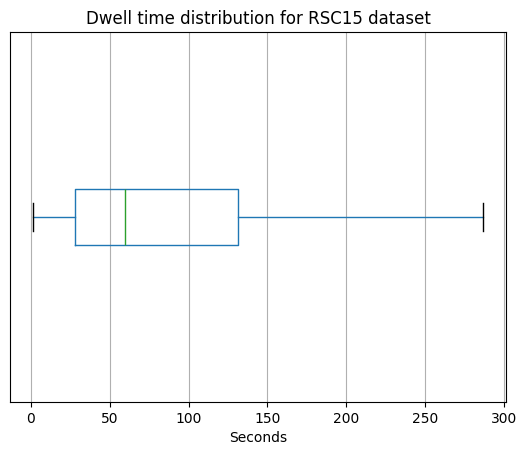

In [18]:
# Visualize
get_distribution(dts)

In [19]:
# threshold is a hyperparameter
join_dwell_reps(new_df, dts, threshold=75)

# augment the sessions copying each entry an additional (dwellReps[i]-1) times
df_aug = augment(new_df)
df_aug.to_csv("./data/augmented_train.csv", index=False, sep='\t')

In [20]:
# retrieve 1/n most recent fraction for demo purposes
# (note it is a smaller fraction due to the inflation process)
fraction = 64*7
train_fraction(df_aug, fraction, prefix='aug_train')

Fractioned data set
	Events: 151923
	Sessions: 16351
	Items: 8484
Saved as ./data/aug_train_448.tsv


## Entrenamiento con Dwell Time

In [21]:
!python src/run.py ./data/aug_train_448.tsv -t ./data/test.tsv -ps n_epochs=50

Creating GRU4Rec model on device "cuda:0"
SET   n_epochs   TO   50   (type: <class 'int'>)
Loading training data...
Loading data from TAB separated file: ./data/aug_train_448.tsv
Started training
The dataframe is already sorted by SessionId, Time
Created sample store with 4882 batches of samples (type=GPU)
Epoch1 --> loss: 3.100188 	(7.24s) 	[309.55 mb/s | 19811 e/s]
Epoch2 --> loss: 2.193132 	(7.04s) 	[318.15 mb/s | 20362 e/s]
Epoch3 --> loss: 1.956753 	(7.11s) 	[315.23 mb/s | 20175 e/s]
Epoch4 --> loss: 1.833859 	(7.07s) 	[316.65 mb/s | 20265 e/s]
Epoch5 --> loss: 1.761578 	(7.10s) 	[315.38 mb/s | 20185 e/s]
Epoch6 --> loss: 1.713052 	(6.98s) 	[320.82 mb/s | 20532 e/s]
Epoch7 --> loss: 1.679286 	(7.05s) 	[317.95 mb/s | 20349 e/s]
Epoch8 --> loss: 1.650939 	(7.10s) 	[315.51 mb/s | 20192 e/s]
Epoch9 --> loss: 1.629673 	(7.08s) 	[316.45 mb/s | 20253 e/s]
Epoch10 --> loss: 1.609814 	(7.10s) 	[315.53 mb/s | 20194 e/s]
Epoch11 --> loss: 1.592917 	(7.07s) 	[316.99 mb/s | 20288 e/s]
Epoch12 

2. Indique el resultado del modelo entrenado con Dwell Time (Recall@k y MRR@k).

**COMPLETE**

3. Compare y comente los resultados obtenidos